# **Rep 3. Checkpoint 2. Black Scholes y Volatility surface**
- Paola Figueroa
- 22/marzo/2026

## **Instrucciones**
Usando el código visto en clase, calcula la volatilidad implícita para al menos 10 strikes distintos del vencimiento 2026-04-17, en el rango [S0 × 0.88, S0 × 1.10].

El precio spot y el precio mid de cada opción deben obtenerse dinámicamente — no hardcodear valores.

Con los resultados, construye dentro de tu código:

Una tabla con columnas: Strike | Bid | Ask | Mid | IV (%)
Una gráfica de IV (%) vs. Strike, con una línea vertical en S0 indicando el precio ATM- . plt.plot(strikes, ivs)

## **1.- Librerías y modelo BS**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import date
from scipy.optimize import brentq, newton

In [2]:
from scipy.stats import norm
import numpy as np

def bs_price(S, K, r, T, sigma, option="call"):
    if sigma <= 0 or T <= 0:
        if option == "call":
            return max(0.0, S - K * np.exp(-r * T))
        else:
            return max(0.0, K * np.exp(-r * T) - S)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option.lower() == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
def bs_vega(S, K, r, T, sigma):
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def implied_vol(price_mkt, S, K, r, T, sigma_hist=0.20, option="call", tol=1e-8, maxiter=100):
    # --- 1. Validación de límites teóricos ---
    if option == "call":
        lower = max(0.0, S - K * np.exp(-r * T))
        upper = S
    else:
        lower = max(0.0, K * np.exp(-r * T) - S)
        upper = K * np.exp(-r * T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        raise ValueError(f"Precio fuera de rango teórico [{lower:.4f},{upper:.4f}]")

    # --- 2. Función objetivo ---
    f = lambda sig: bs_price(S, K, r, T, sig, option) - price_mkt

    # --- 3. Amplía intervalo si f no cambia de signo ---
    a, b = 1e-6, 5.0
    if f(a) * f(b) > 0:
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            if f(a) * f(b_try) <= 0:
                b = b_try
                break

    # --- 4. Método de Brent (robusto, principal) ---
    try:
        return brentq(f, a, b, xtol=tol, maxiter=maxiter)
    except Exception:
        pass

    # --- 5. Newton–Raphson (rápido, respaldo) ---
    try:
        iv = newton(f, x0=sigma_hist,
                    fprime=lambda s: bs_vega(S, K, r, T, s),
                    tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv
    except Exception:
        pass

    raise RuntimeError("No se pudo encontrar la IV con ningún método.")

## **2.- So, T y opciones**

In [3]:
ticker = 'SPY'
exp    = '2026-04-17'
r      = 0.042     

# So
tk   = yf.Ticker(ticker)
hist = yf.download(ticker, period='5d', progress=False)

if isinstance(hist.columns, pd.MultiIndex):
    hist.columns = hist.columns.get_level_values(0)
S0 = float(hist['Close'].iloc[-1])


# T
today = date.today()
T     = (date.fromisoformat(exp) - today).days / 365

# Volatilidad Histórica
hist_long = yf.download(ticker, start='2022-01-01', end=today, progress=False)
if isinstance(hist_long.columns, pd.MultiIndex):
    hist_long.columns = hist_long.columns.get_level_values(0)
sigma_hist = float(hist_long['Close'].pct_change().dropna().std() * np.sqrt(252))

print(f"Ticker : {ticker}")
print(f"Hoy    : {today}")
print(f"S0     : {S0:.2f}")
print(f"Exp    : {exp}  →  T = {T:.4f} años ({round(T*365)} días)")
print(f"sigma_hist : {sigma_hist:.2%}")
print(f"Rango  : [{S0*0.88:.2f}, {S0*1.10:.2f}]")

Ticker : SPY
Hoy    : 2026-03-22
S0     : 648.57
Exp    : 2026-04-17  →  T = 0.0712 años (26 días)
sigma_hist : 17.77%
Rango  : [570.74, 713.43]


## **3.- Cálculo de Volatilidad Implícita**

In [4]:
# Ver qué strikes están disponibles
calls_raw = tk.option_chain(exp).calls.copy()
print("Columnas disponibles:", calls_raw.columns.tolist())
print(f"Total strikes en la cadena: {len(calls_raw)}")
print(f"\nStrikes en rango [S0×0.88={S0*0.88:.2f}, S0×1.10={S0*1.10:.2f}]:")
en_rango = calls_raw[
    (calls_raw['strike'] >= S0 * 0.88) &
    (calls_raw['strike'] <= S0 * 1.10)
]
print(en_rango[['strike','bid','ask','volume','openInterest']].to_string(index=False))

Columnas disponibles: ['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']
Total strikes en la cadena: 222

Strikes en rango [S0×0.88=570.74, S0×1.10=713.43]:
 strike   bid   ask  volume  openInterest
  575.0 77.85 80.62     3.0            22
  580.0 73.14 75.92     4.0            80
  585.0 68.47 71.27    42.0           139
  590.0 63.95 66.66    38.0            44
  595.0 59.32 62.11     2.0            67
  600.0 54.82 57.56  1496.0           263
  605.0 50.42 53.18    18.0            91
  610.0 46.09 48.90   156.0           575
  615.0 41.96 44.69    45.0            76
  620.0 37.77 40.54   163.0          1118
  625.0 33.86 36.60    90.0           282
  626.0 33.02 35.83     1.0             3
  627.0 32.33 35.05     1.0             2
  628.0 31.48 34.29     5.0             4
  629.0 30.73 33.53     NaN             2
  630.0 30.64 32.68    37.0      

In [5]:
mask = (
    (calls_raw['strike'] >= S0 * 0.88) &
    (calls_raw['strike'] <= S0 * 1.10) &
    (calls_raw['bid']    >= 0) &   
    (calls_raw['ask']    >  0)     
)
calls_filtered = calls_raw[mask].copy()

# Precio Mid
calls_filtered['mid'] = (calls_filtered['bid'] + calls_filtered['ask']) / 2

# Para calls muy con bid=0, usar el ask directamente como precio de mercado
calls_filtered.loc[calls_filtered['bid'] == 0, 'mid'] = calls_filtered.loc[calls_filtered['bid'] == 0, 'ask']

# 10 strikes
all_strikes = calls_filtered['strike'].values
n_sel       = min(10, len(all_strikes))
idx_sel     = np.linspace(0, len(all_strikes) - 1, n_sel, dtype=int)
strikes_sel = all_strikes[idx_sel]
calls_sel   = calls_filtered[calls_filtered['strike'].isin(strikes_sel)].copy()

# Cálculo de IV
results = []
for _, row in calls_sel.iterrows():
    K   = row['strike']
    bid = row['bid']
    ask = row['ask']
    mid = row['mid']
    try:
        iv = implied_vol(mid, S0, K, r, T, sigma_hist=sigma_hist, option='call')
        if 0.01 <= iv <= 5.0:   
            results.append({'Strike': K, 'Bid': bid, 'Ask': ask, 'Mid': round(mid, 4), 'IV (%)': round(iv * 100, 2)})
        else:
            print(f"  IV fuera de rango para K={K:.0f}: {iv:.4f}")
    except Exception as e:
        print(f"  Error en K={K:.0f}: {e}")

print(f"\nStrikes con IV calculada: {len(results)}")


Strikes con IV calculada: 10


## **4. Tabla**

In [9]:
df_iv = pd.DataFrame(results)

df_iv = df_iv.round({'Bid': 2, 'Ask': 2, 'Mid': 4, 'IV (%)': 2})
df_iv.index = df_iv.index + 1
df_iv

,Strike,Bid,Ask,Mid,IV (%)
1,575.0,77.85,80.62,79.235,39.87
2,625.0,33.86,36.60,35.230,29.54
3,637.0,25.91,26.44,26.175,27.33
4,648.0,18.78,19.05,18.915,25.59
5,659.0,12.43,12.52,12.475,23.54
6,669.0,7.60,7.68,7.640,21.56
7,680.0,3.68,3.73,3.705,19.34
8,691.0,1.38,1.43,1.405,17.38
9,702.0,0.43,0.46,0.445,16.12
10,713.0,0.14,0.16,0.150,15.80


## **5.- Gráfica IV vs. Strike**

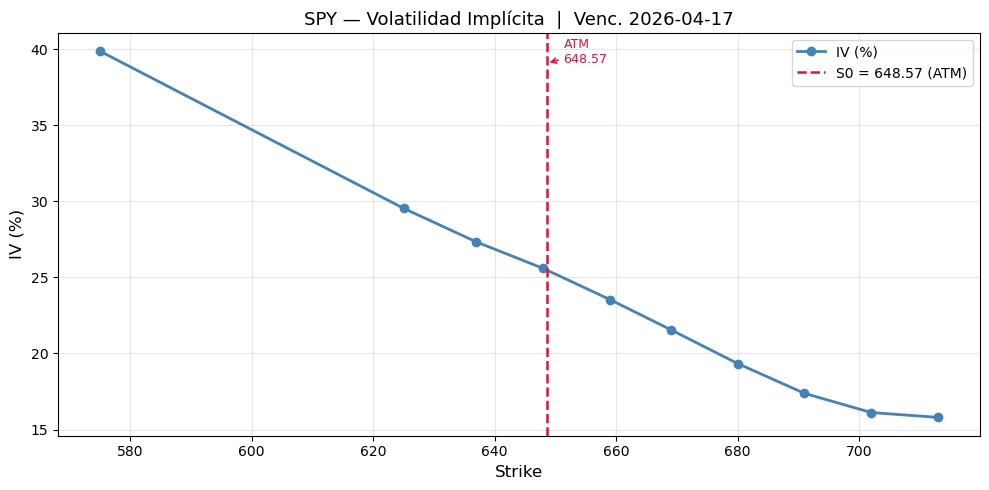

In [10]:
strikes = df_iv['Strike'].values
ivs     = df_iv['IV (%)'].values

fig, ax = plt.subplots(figsize=(10, 5))

# Curva de volatilidad (requerida por el enunciado)
plt.plot(strikes, ivs, 'o-', color='steelblue', linewidth=2,
         markersize=6, label='IV (%)')

# Línea vertical en S0 → indica el precio ATM
ax.axvline(x=S0, color='crimson', linestyle='--', linewidth=1.8,
           label=f'S0 = {S0:.2f} (ATM)')

# Anotación del nivel ATM
ax.annotate(f'ATM\n{S0:.2f}',
            xy=(S0, max(ivs) * 0.98),
            xytext=(S0 + (strikes[-1] - strikes[0]) * 0.02, max(ivs) * 0.98),
            fontsize=9, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))

ax.set_xlabel('Strike',   fontsize=12)
ax.set_ylabel('IV (%)',   fontsize=12)
ax.set_title(f'{ticker} — Volatilidad Implícita  |  Venc. {exp}', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **6.- Preguntas**
- ¿La curva de IV es decreciente, creciente o tiene forma de smile? ¿Qué implica eso?
    - Es decreciente de izquierda a derecha, lo que significa que las opciones OTM hacia abajo (puts baratas en strike) tienen una volatilidad implícita más alta que las calls OTM hacia arriba. El mercado le asigna más probabilidad a caídas bruscas que a subidas del mismo tamaño. 
- ¿En qué strike es mínima la IV? ¿Coincide con S0?
    - La IV mínima suele estar cerca del ATM pero no exactamente en S0 (generalmente cae un poco por encima, en la zona de calls ligeramente OTM). Esto pasa porque el skew "jala" la curva hacia la izquierda, así que el punto más bajo no es el spot exacto sino un strike levemente mayor.
- ¿Qué estarían comprando los inversores que pagan una IV alta en strikes bajos?
    - Protección. Básicamente están comprando puts OTM como seguro de cartera( ej. si el mercado cae 10-15%, esas opciones se disparan en valor). El hecho de que paguen una IV inflada por esas puts refleja la demanda de cobertura: fondos, institucionales y cualquiera con posición larga en renta variable quiere protegerse de un crash. Esa prima extra sobre el valor teórico de BS es el costo del miedo.
- ¿Qué le diría esta curva a alguien que quiere usar Black–Scholes con una sola volatilidad constante?
    - Que está simplificando demasiado. Black-Scholes asume que la volatilidad es la misma para todos los strikes, pero la curva está diciendo claramente que no lo es, pues cada strike tiene su propio mundo de volatilidad. Si usamos una sola sigma, estaríamos subvaluando las puts OTM (que tienen IV alta) y potencialmente sobrevaluando las calls OTM. 